### **K-Nearest Neighbors: Predicting Customer Churn**

#### Objective:
Your task is to build a **K-Nearest Neighbors (KNN)** classifier to predict whether a customer will churn or stay based on their usage patterns and demographic data. This will help you understand how KNN works for classification and explore its strengths and limitations.

---

#### Dataset:
Use the **Customer Churn Dataset**, available from:
- [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
- Or other sources such as open repositories.

Alternatively, you can create a simulated churn dataset using Python's libraries like `sklearn.datasets.make_classification`.

---

#### Dataset Overview:
Key features:
- **Demographic Information**: `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- **Account Details**: `tenure`, `Contract`, `MonthlyCharges`, `TotalCharges`
- **Services Used**: `PhoneService`, `MultipleLines`, `InternetService`, etc.

Target variable:
- **Churn**: Binary column indicating whether a customer churned (`Yes` or `No`).

---

#### Steps to Complete:

1. **Load the Dataset**
   - Import the dataset using `pandas`.
   - Display the first few rows to understand the structure.
   - Identify categorical and numerical columns.

2. **Data Exploration**
   - Check the distribution of the target variable (`Churn`).
   - Explore correlations between numerical features (e.g., `tenure`, `MonthlyCharges`, `TotalCharges`) and `Churn`.
   - Use group-by operations to analyze churn rates across different categories (e.g., `Contract`, `InternetService`).

3. **Data Cleaning**
   - Handle missing values (e.g., `TotalCharges` might have nulls).
   - Encode categorical features using one-hot encoding or label encoding.
   - Normalize/scale numerical features (important for KNN).

4. **Data Splitting**
   - Split the dataset into training (80%) and testing (20%) sets using `train_test_split`.

5. **Build and Evaluate KNN Model**
   - Train a KNN classifier using `KNeighborsClassifier` from `sklearn.neighbors`.
   - Use the default value of `k` (number of neighbors).
   - Evaluate the model on the test set using:
     - **Accuracy**
     - **Confusion Matrix**
     - **Classification Report** (precision, recall, F1-score)

6. **Optimize the K Value**
   - Experiment with different values of `k` (e.g., 1, 3, 5, 7, 10).
   - Plot a graph of `k` vs. accuracy to identify the optimal value.
   - Use cross-validation to confirm the chosen `k`.

7. **Compare Distance Metrics**
   - Train and evaluate the KNN model with different distance metrics:
     - **Euclidean distance** (default)
     - **Manhattan distance**
     - **Minkowski distance**
   - Analyze which metric works best for this dataset.

8. **Insights**
   - Discuss the overall performance of the KNN model.
   - Highlight the importance of scaling and choosing an optimal `k`.
   - Reflect on potential challenges when using KNN for larger datasets.

---

#### Bonus Challenges (Optional):

1. **Feature Selection**
   - Use feature importance techniques (e.g., correlation analysis or mutual information) to identify the most relevant features.
   - Train the KNN model using only these features and compare its performance to the full model.

2. **Customer Profiling**
   - Create customer profiles (e.g., high risk, low risk) based on their churn probabilities.

3. **Comparison with Other Models**
   - Compare KNN's performance to other models like:
     - **Logistic Regression**
     - **Random Forest**

4. **Advanced Visualization**
   - Use **t-SNE** or **PCA** to reduce the feature space to 2D and visualize the clusters of churned and non-churned customers.

---

#### Deliverables:
- A Python script or Jupyter Notebook containing:
  - Data exploration, cleaning, and preprocessing.
  - Implementation of KNN with optimized `k` and distance metrics.
  - Visualizations (e.g., churn distributions, `k` vs. accuracy plot).
- A brief report discussing:
  - Key insights from the dataset.
  - How the model performs with different `k` values and distance metrics.
  - Challenges encountered during data preparation or modeling.

---

#### Useful Hints:
- Use `seaborn` for visualizations like heatmaps and bar plots.
- Normalize numerical features using `StandardScaler` or `MinMaxScaler` to ensure fair distance calculations.
- For imbalanced datasets, consider using `stratify` in `train_test_split`.



In [1]:
# KNN: Predicting Customer Churn

# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
# Load dataset (update path if needed)
df = pd.read_csv("data/TelcoCustomerChurn.csv")

# Preview
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


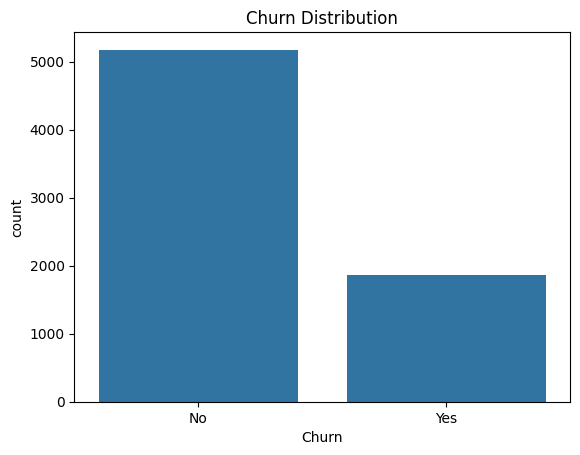

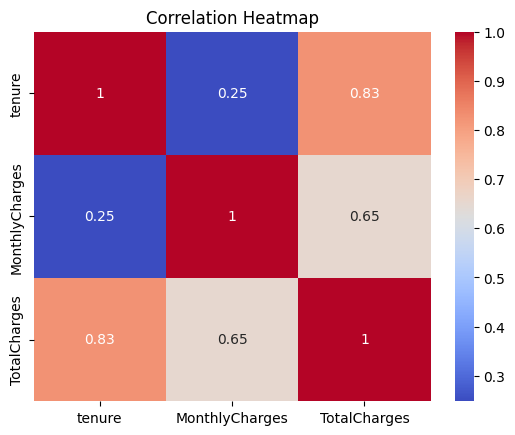

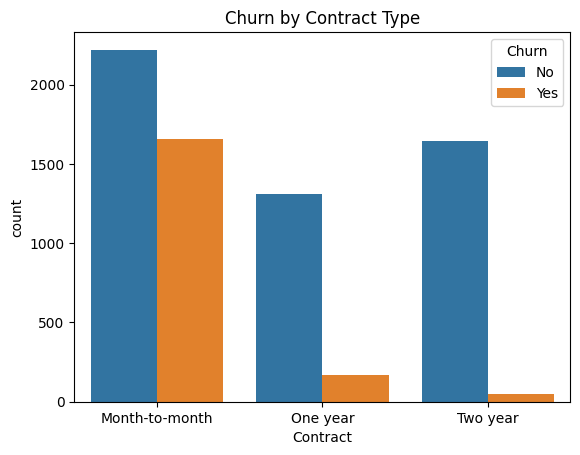

In [3]:
# Target distribution
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

# Numerical correlations
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Churn by Contract
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()


In [4]:
# Handle missing values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Drop irrelevant columns
df.drop(["customerID"], axis=1, inplace=True)

# Encode categorical variables
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    if col != "Churn":
        df[col] = LabelEncoder().fit_transform(df[col])

# Encode target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Scale features
X = df.drop("Churn", axis=1)
y = df["Churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


C:\Users\Mezon\AppData\Local\Temp\ipykernel_324\2073742949.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)


Accuracy: 0.7409510290986515

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.83      0.82      1035
           1       0.51      0.50      0.51       374

    accuracy                           0.74      1409
   macro avg       0.67      0.66      0.67      1409
weighted avg       0.74      0.74      0.74      1409



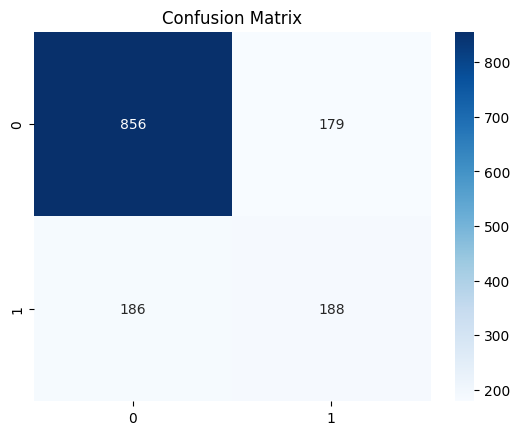

In [6]:
knn = KNeighborsClassifier(n_neighbors=5)  # default k=5
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


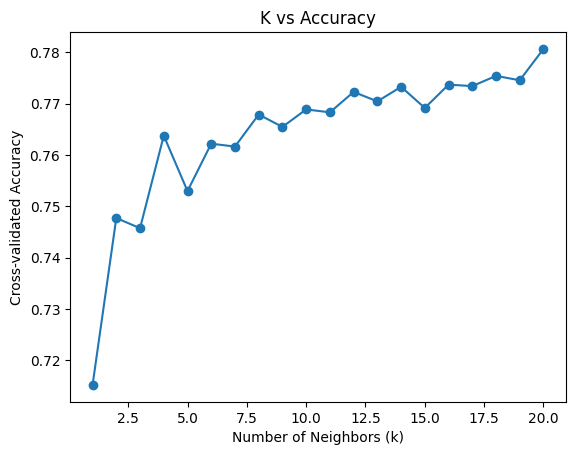

Best k value: 20


In [7]:
k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring="accuracy")
    accuracies.append(scores.mean())

plt.plot(k_range, accuracies, marker="o")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-validated Accuracy")
plt.title("K vs Accuracy")
plt.show()

best_k = k_range[np.argmax(accuracies)]
print("Best k value:", best_k)


In [8]:
metrics = ["euclidean", "manhattan", "minkowski"]
for m in metrics:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=m)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print(f"\nDistance Metric: {m}")
    print("Accuracy:", accuracy_score(y_test, y_pred))



Distance Metric: euclidean
Accuracy: 0.7792760823278921

Distance Metric: manhattan
Accuracy: 0.7835344215755855

Distance Metric: minkowski
Accuracy: 0.7792760823278921
